In [4]:
import numpy as np
import pandas as pd
import os 



import warnings
warnings.filterwarnings('ignore')

# Choose directory
directory = "C:/Users/Fede/OneDrive/Projects/prorindes"
os.chdir(directory)

files_datain = "data/raw_data/"
files_dataout = "data/processed_data/"
files_plots = "plots/"


In [5]:

# scripts with all plot packages and functions
from Scripts.functions_plots import * 
# create_base_map, facet_plot, map_plot, pyplot package and others

# precipitation data

In [6]:
# import precipitation file
df = pd.read_csv(files_datain + "precipitation.csv")

# convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# import prorindes dataframe
df_locations = pd.read_csv(files_dataout+  "/location_info.csv")

# Filter data
From the raw data, there are two locations that we do not use. To filter, we make inner join using the csv with location information (obtained from the *1. yield_climatology* jupyter file)


In [7]:
df = pd.merge(df.copy(), df_locations, 
                left_on="omm_id", right_on="wmm_id", how="inner")

Next, we filter the data in terms of **time**
 - Year should be until 2017
 - Remove the 29th of February
 - Create column with Julian day (leap years are shifted to be in 1-365 format)

In [8]:
# Keep years <= 2017
df = df.loc[df["date"].dt.year <= 2017].copy()

# Remove Feb 29
mask_feb29 = (df["date"].dt.month == 2) & (df["date"].dt.day == 29)
df = df.loc[~mask_feb29].copy()

df["year"] = df["date"].dt.year

# Julian day adjusted to always be 1..365
df["julian_day"] = df["date"].dt.dayofyear

mask = df["date"].dt.is_leap_year & (df["julian_day"] > 59)
df.loc[mask, "julian_day"] -= 1

### order data

In [9]:
# create an array of unique values of wmm id
wmoids = df["wmm_id"].unique()
df= df.drop(columns= "wmm_id")

# reorder categories!!
# reorder categories!!
orden = ["Reconquista","Paraná","Gualeguaychú","Río Cuarto","Marcos Juárez",
         "Laboulaye","Junín","Pehuajó","Nueve de Julio","Coronel Suárez","Tandil","Tres Arroyos"]
df['location'] = df["location"].astype("category")
df['location'] = df['location'].cat.reorder_categories(orden)

# Create precipitation indices

In [10]:
# Ensure data are sorted
df = df.sort_values(["location", "julian_day","year"])


w= 30
# 1. Cumulative precipitation
df[f"prcp_sum_{w}_rollmean5"] = (
    df.groupby(["location","year"])["prcp"]
      .transform(lambda x: x.rolling(w, min_periods=w).sum().rolling(5, min_periods=5).mean()  )
)



# CLimatology of index

In [11]:
col = "prcp_sum_30_rollmean5"
df_summary = df.groupby(["location","julian_day"]).apply(
    lambda g: pd.Series(
        {"prcp_sum_30_rollmean5_median":g[col].quantile(0.5),
       "prcp_sum_30_rollmean5_q05":g[col].quantile(0.05),
       "prcp_sum_30_rollmean5_q95":g[col].quantile(0.95)}
    )
).reset_index()

### plots

In [12]:
df_summary.columns

Index(['location', 'julian_day', 'prcp_sum_30_rollmean5_median',
       'prcp_sum_30_rollmean5_q05', 'prcp_sum_30_rollmean5_q95'],
      dtype='object')

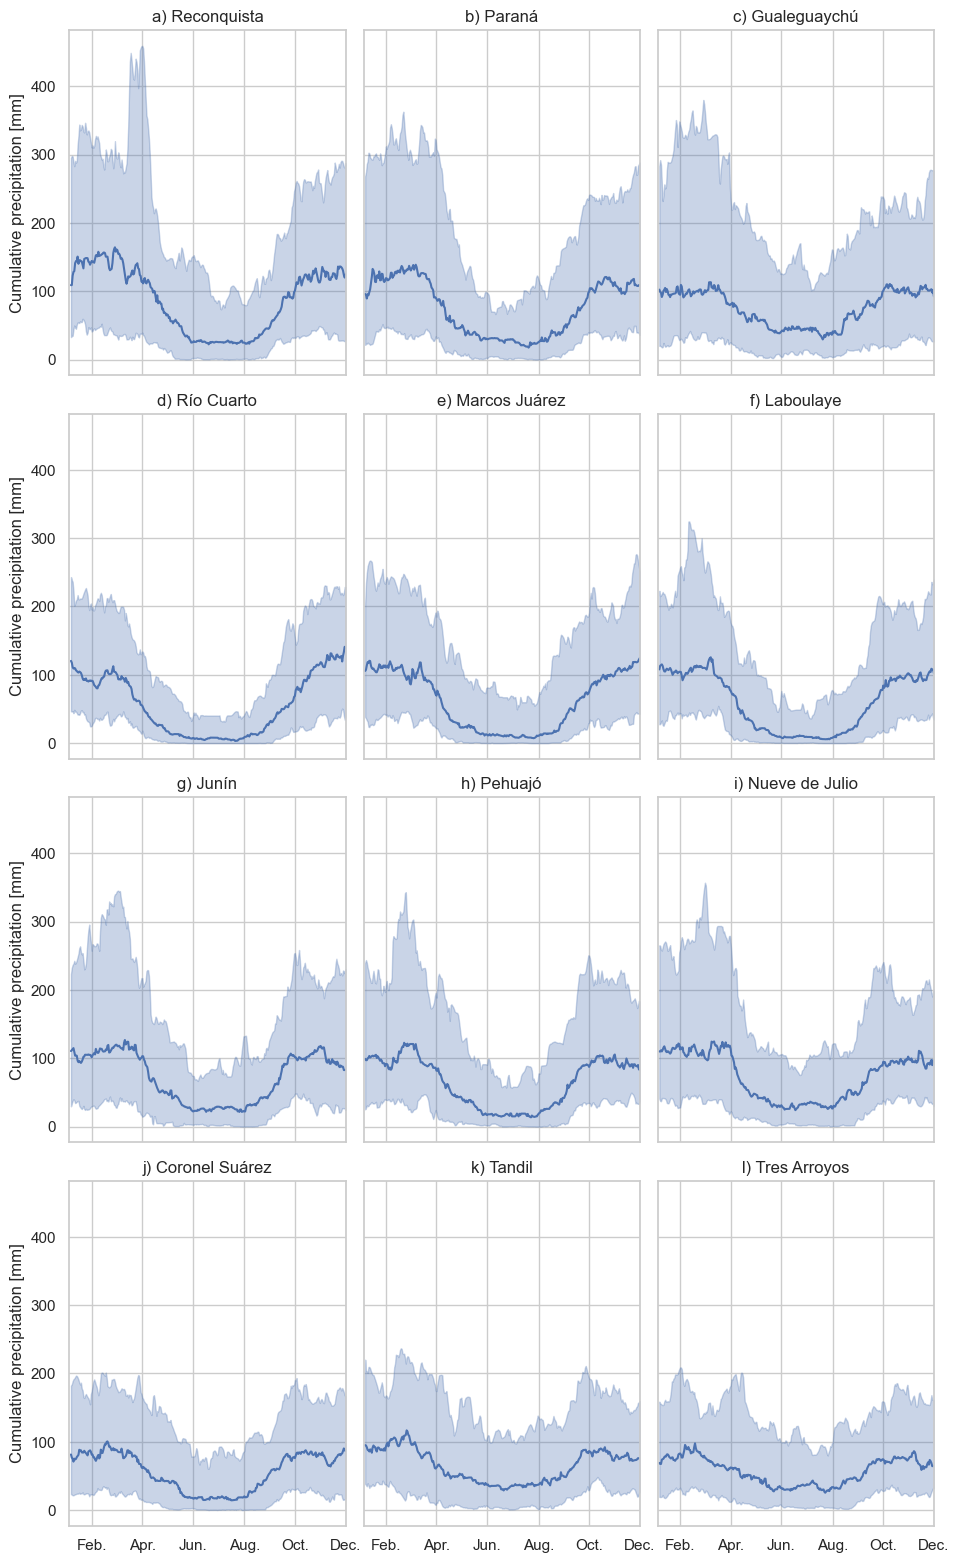

In [21]:
g = facet_plot(
    df_summary,
    sns.lineplot, 
    col="location",
    height=4,aspect=0.8,
    x="julian_day",
    y="prcp_sum_30_rollmean5_median",
    hue=None,
    palette=None,
    legend_title=None,
    legend=False
)


g.map(
    plt.fill_between,
    "julian_day", "prcp_sum_30_rollmean5_q05" ,  "prcp_sum_30_rollmean5_q95",
    alpha=0.3
)

g.set(xlabel = "",
      ylabel="Cumulative precipitation [mm]",
    xticks = [59, 120, 181, 243, 304, 365],
    xticklabels = ['Feb.', 'Apr.', 'Jun.','Aug.', 'Oct.', 'Dec.'],
    xlim=(32,365))



plt.savefig(files_plots + "variable_climatology_" + col  + ".png",dpi=300,bbox_inches='tight')

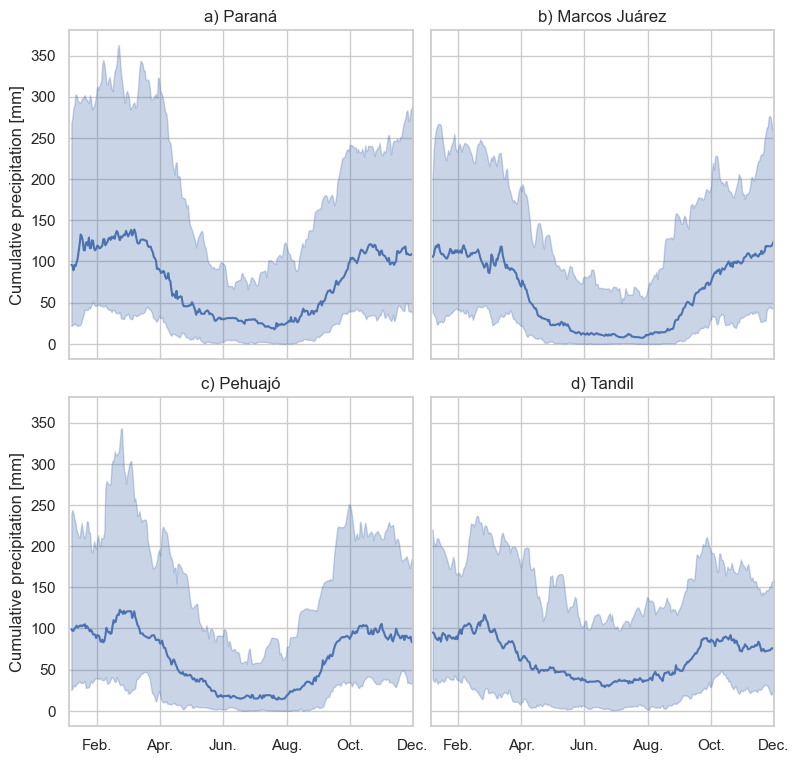

In [23]:
subgroup = ["Paraná","Marcos Juárez","Pehuajó","Tandil"]
df_sub = df_summary[df_summary["location"].isin(subgroup)].copy()

df_sub["location"] = (
    df_sub["location"]
    .cat.remove_unused_categories()
)

g = facet_plot(
    df_sub,
    sns.lineplot, 
    col="location",
    col_wrap=2,
    height=4,aspect=1,
    x="julian_day",
    y="prcp_sum_30_rollmean5_median",
    hue=None,
    palette=None,
    legend_title=None,
    legend=False
)


g.map(
    plt.fill_between,
    "julian_day", "prcp_sum_30_rollmean5_q05" ,  "prcp_sum_30_rollmean5_q95",
    alpha=0.3
)

g.set(xlabel = "",
      ylabel="Cumulative precipitation [mm]",
    xticks = [59, 120, 181, 243, 304, 365],
    xticklabels = ['Feb.', 'Apr.', 'Jun.','Aug.', 'Oct.', 'Dec.'],
    xlim=(32,365))


plt.savefig(files_plots + "variable_climatology_" + col  + "_subgroup.png",dpi=300,bbox_inches='tight')

# save file (df)

In [15]:
df.to_csv(files_dataout + "precipitation_new.csv",index=False)